Import required libraries for neural network:

In [ ]:
import tensorflow as tf
import pandas as pd
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

Splitting data for 80% train and 20% test for validation:

In [2]:
df = pd.read_csv(r'data/othello_training_data_fixed.csv')

In [3]:
X = df.drop(columns=['score']).values
y = df['score'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model and layers:

First version with normal NN:

In [ ]:
#model = models.Sequential([
    layers.Input(shape=(36,)),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(8, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
#])

CNN Version for enhanced model performance and winrate:

In [ ]:
model = models.Sequential([
    # flat list of 36 board squares
    layers.Input(shap=(36,)),
    layers.Reshape((6,6,1)), # make board 6*6
    # put 32 3*3s over the board to find patterns
    layers.Conv2D(32, kernel_size=(3, 3), padding="same", activation="relu"),
    # put 64 3*3s to spot more complex patterns
    layers.Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu"),
    # putting 2D back into linear
    layers.Flatten(),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(8, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

In [5]:
model.compile(optimizer="adam", loss="mse", metrics=['mae'])

In [6]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True   # Keep the best model weights
)

In [7]:
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), batch_size=64, callbacks=[early_stopping])

Epoch 1/50
19822/19822 ━━━━━━━━━━━━━━━━━━━━ 76s 4ms/step - loss: 0.0455 - mae: 0.1466 - val_loss: 0.0402 - val_mae: 0.1368
Epoch 2/50
19822/19822 ━━━━━━━━━━━━━━━━━━━━ 73s 4ms/step - loss: 0.0425 - mae: 0.1408 - val_loss: 0.0398 - val_mae: 0.1347
Epoch 3/50
19822/19822 ━━━━━━━━━━━━━━━━━━━━ 76s 4ms/step - loss: 0.0422 - mae: 0.1401 - val_loss: 0.0398 - val_mae: 0.1355
Epoch 4/50
19822/19822 ━━━━━━━━━━━━━━━━━━━━ 72s 4ms/step - loss: 0.0421 - mae: 0.1398 - val_loss: 0.0395 - val_mae: 0.1346
Epoch 5/50
19822/19822 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - loss: 0.0420 - mae: 0.1394 - val_loss: 0.0398 - val_mae: 0.1351
Epoch 6/50
19822/19822 ━━━━━━━━━━━━━━━━━━━━ 69s 3ms/step - loss: 0.0419 - mae: 0.1393 - val_loss: 0.0395 - val_mae: 0.1333
Epoch 7/50
19822/19822 ━━━━━━━━━━━━━━━━━━━━ 76s 4ms/step - loss: 0.0418 - mae: 0.1390 - val_loss: 0.0394 - val_mae: 0.1347
Epoch 8/50
19822/19822 ━━━━━━━━━━━━━━━━━━━━ 74s 4ms/step - loss: 0.0418 - mae: 0.1389 - val_loss: 0.0392 - val_mae: 0.1344
Epoch 9/50
19822

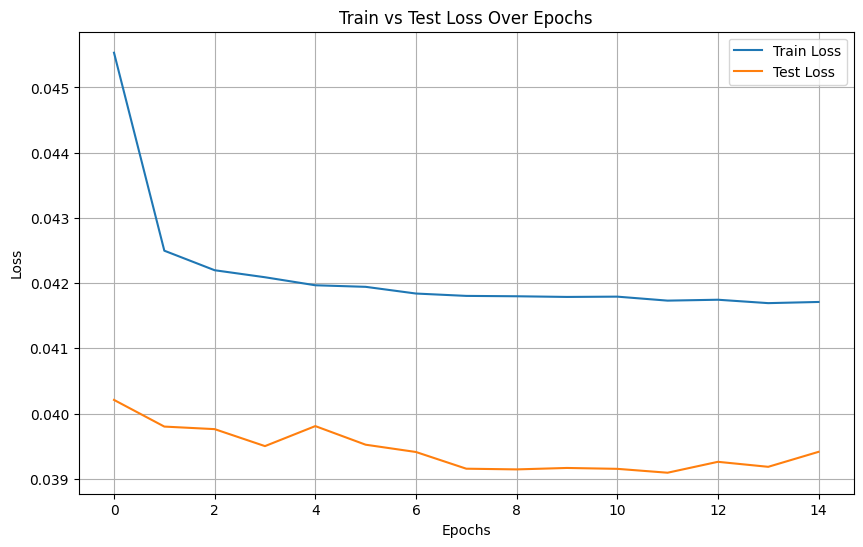

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Train vs Test Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [9]:
model.save('othello_model.keras')